# Importing Libraries

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load The Dataset

In [4]:
dataset=pd.read_csv("/Users/princegupta/Documents/ML_PROJECTS/Loan_Prediction/loan_approval_dataset.csv")

# Exploring Dataset

In [6]:
dataset.head(5)

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


getting the overwiew of the dataset by reviewing top 5 rows

In [8]:
dataset.shape

(4269, 13)

checking no. of rows and columns 

In [10]:
dataset.describe()

,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03
mean,2135.000000,2.498712,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06
std,1232.498479,1.695910,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06
min,1.000000,0.000000,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00
25%,1068.000000,1.000000,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06
50%,2135.000000,3.000000,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06
75%,3202.000000,4.000000,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06
max,4269.000000,5.000000,9.900000e+06,3.950000e+07,20.000000,900.000000,2.910000e+07,1.940000e+07,3.920000e+07,1.470000e+07


Statistical Analysis
numeriical feature laon_id : indicates that there are 1 to 4269 applicants no_of_dependents:indicates that applicants have are 0 to maximum 5 dependents income_annum : indicates income of applicants are 200000 to maximum 9900000 laon_amount: indicating that the amount of loan requested by the applicants is minimum 300000 to maximum 39500000 75% of bank_asset values are below 7100000

In [12]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   loan_id                    4269 non-null   int64 
 1    no_of_dependents          4269 non-null   int64 
 2    education                 4269 non-null   object
 3    self_employed             4269 non-null   object
 4    income_annum              4269 non-null   int64 
 5    loan_amount               4269 non-null   int64 
 6    loan_term                 4269 non-null   int64 
 7    cibil_score               4269 non-null   int64 
 8    residential_assets_value  4269 non-null   int64 
 9    commercial_assets_value   4269 non-null   int64 
 10   luxury_assets_value       4269 non-null   int64 
 11   bank_asset_value          4269 non-null   int64 
 12   loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


dataset has both numeric and catagorical data

In [14]:
dataset.nunique()

loan_id                      4269
 no_of_dependents               6
 education                      2
 self_employed                  2
 income_annum                  98
 loan_amount                  378
 loan_term                     10
 cibil_score                  601
 residential_assets_value     278
 commercial_assets_value      188
 luxury_assets_value          379
 bank_asset_value             146
 loan_status                    2
dtype: int64

catagorical feature :eduaction, self_emplyed and laon_status each has 2 unique values respectively [Graduate,Not],[No,Yes],[Approved,Rejected]

# checking for null values

In [17]:
dataset.isnull().sum()

loan_id                      0
 no_of_dependents            0
 education                   0
 self_employed               0
 income_annum                0
 loan_amount                 0
 loan_term                   0
 cibil_score                 0
 residential_assets_value    0
 commercial_assets_value     0
 luxury_assets_value         0
 bank_asset_value            0
 loan_status                 0
dtype: int64

no null values in the dataset

In [19]:
dataset.duplicated().sum()

np.int64(0)

there are no duplicates in the dataset

In [21]:
dataset.columns

Index(['loan_id', ' no_of_dependents', ' education', ' self_employed',
       ' income_annum', ' loan_amount', ' loan_term', ' cibil_score',
       ' residential_assets_value', ' commercial_assets_value',
       ' luxury_assets_value', ' bank_asset_value', ' loan_status'],
      dtype='object')

# Removing unecessary spaces in Columns name and Column values , since it can produce unecessary errors in future

In [23]:
dataset.columns=dataset.columns.str.strip()
dataset.columns

Index(['loan_id', 'no_of_dependents', 'education', 'self_employed',
       'income_annum', 'loan_amount', 'loan_term', 'cibil_score',
       'residential_assets_value', 'commercial_assets_value',
       'luxury_assets_value', 'bank_asset_value', 'loan_status'],
      dtype='object')

# Outliers Minning

# Detecting Outlier by Visualization

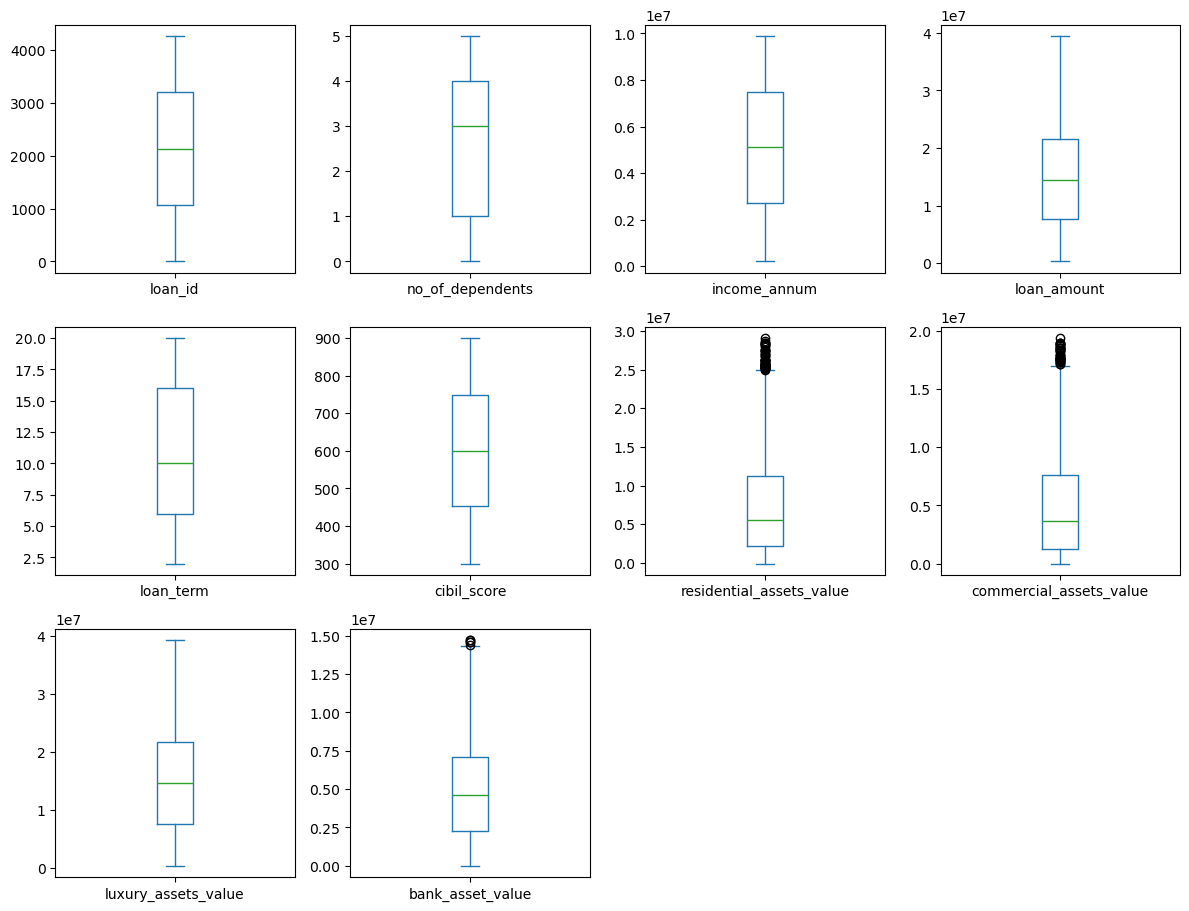

In [26]:
dataset.plot(kind='box', figsize= (12,12), layout=(4,4), sharex= False, subplots= True) ;plt.tight_layout()

Outliers detected in features bank_asset_value :indicating there are few applicants having more than 1400000 in their bank accounts residentoal_assets_value and commercial_assets_value : indicating there are few applicants having more value of residential and commercial assets

# Visualizing Outliers For residential_assets_value 

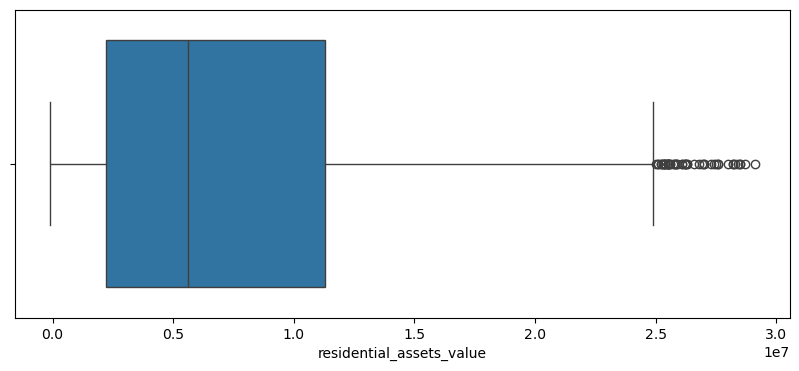

In [29]:
plt.figure(figsize=(10,4))
sns.boxplot(x='residential_assets_value', data=dataset)
plt.show()

# Visualizing Outliers For commercial_assets_value

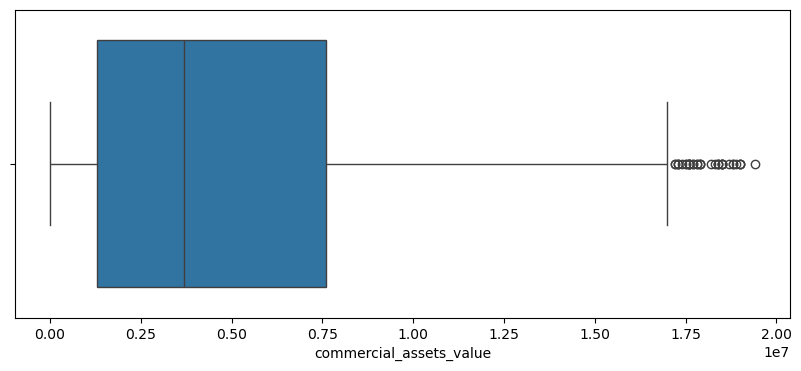

In [31]:
plt.figure(figsize=(10,4))
sns.boxplot(x='commercial_assets_value', data=dataset)
plt.show()

# Removing Outliers

In [33]:
q1=dataset["residential_assets_value"].quantile(0.25)
q3=dataset["residential_assets_value"].quantile(0.75)

Calculating q1 and q3

In [35]:
IQR=q3-q1

calculating IQR

In [37]:
min_range=q1-(1.5*IQR)
max_range=q3+(1.5*IQR)
min_range,max_range

(np.float64(-11450000.0), np.float64(24950000.0))

min_range and max_range

In [39]:
dataset=dataset[dataset["residential_assets_value"]<max_range]

defining max_range to remove the outliers

# visualizing residential_assets_value after removing outlier 

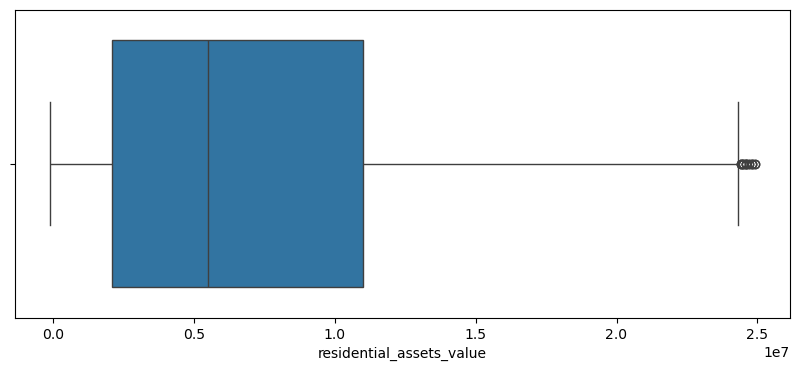

In [42]:
plt.figure(figsize=(10,4))
sns.boxplot(x='residential_assets_value', data=dataset)
plt.show()

In [43]:
q_1=dataset["commercial_assets_value"].quantile(0.25)
q_3=dataset["commercial_assets_value"].quantile(0.75)

calculating q1 and q3 for residential_assets_value

In [45]:
iqr=q_3-q_1

calculating iqr for residential_assets_value

In [47]:
min_range_1=q_1-(1.5*iqr)
max_range_1=q_3+(1.5*iqr)
min_range_1,max_range_1

(np.float64(-8150000.0), np.float64(17050000.0))

In [48]:
dataset=dataset[dataset["commercial_assets_value"]<max_range_1]

defining max_range to remove the extra value outside the max_range

# visualizing commercial_assets_value after removing outliers

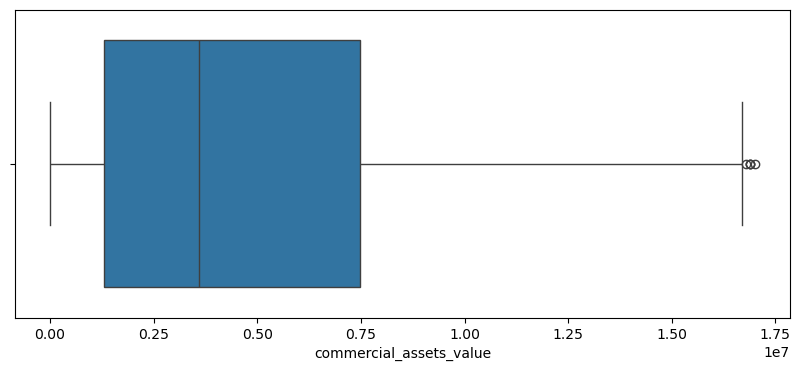

In [51]:
plt.figure(figsize=(10,4))
sns.boxplot(x="commercial_assets_value",data=dataset)
plt.show()

# visualizing all possible graph for the dataset columns

<Figure size 1000x1000 with 0 Axes>

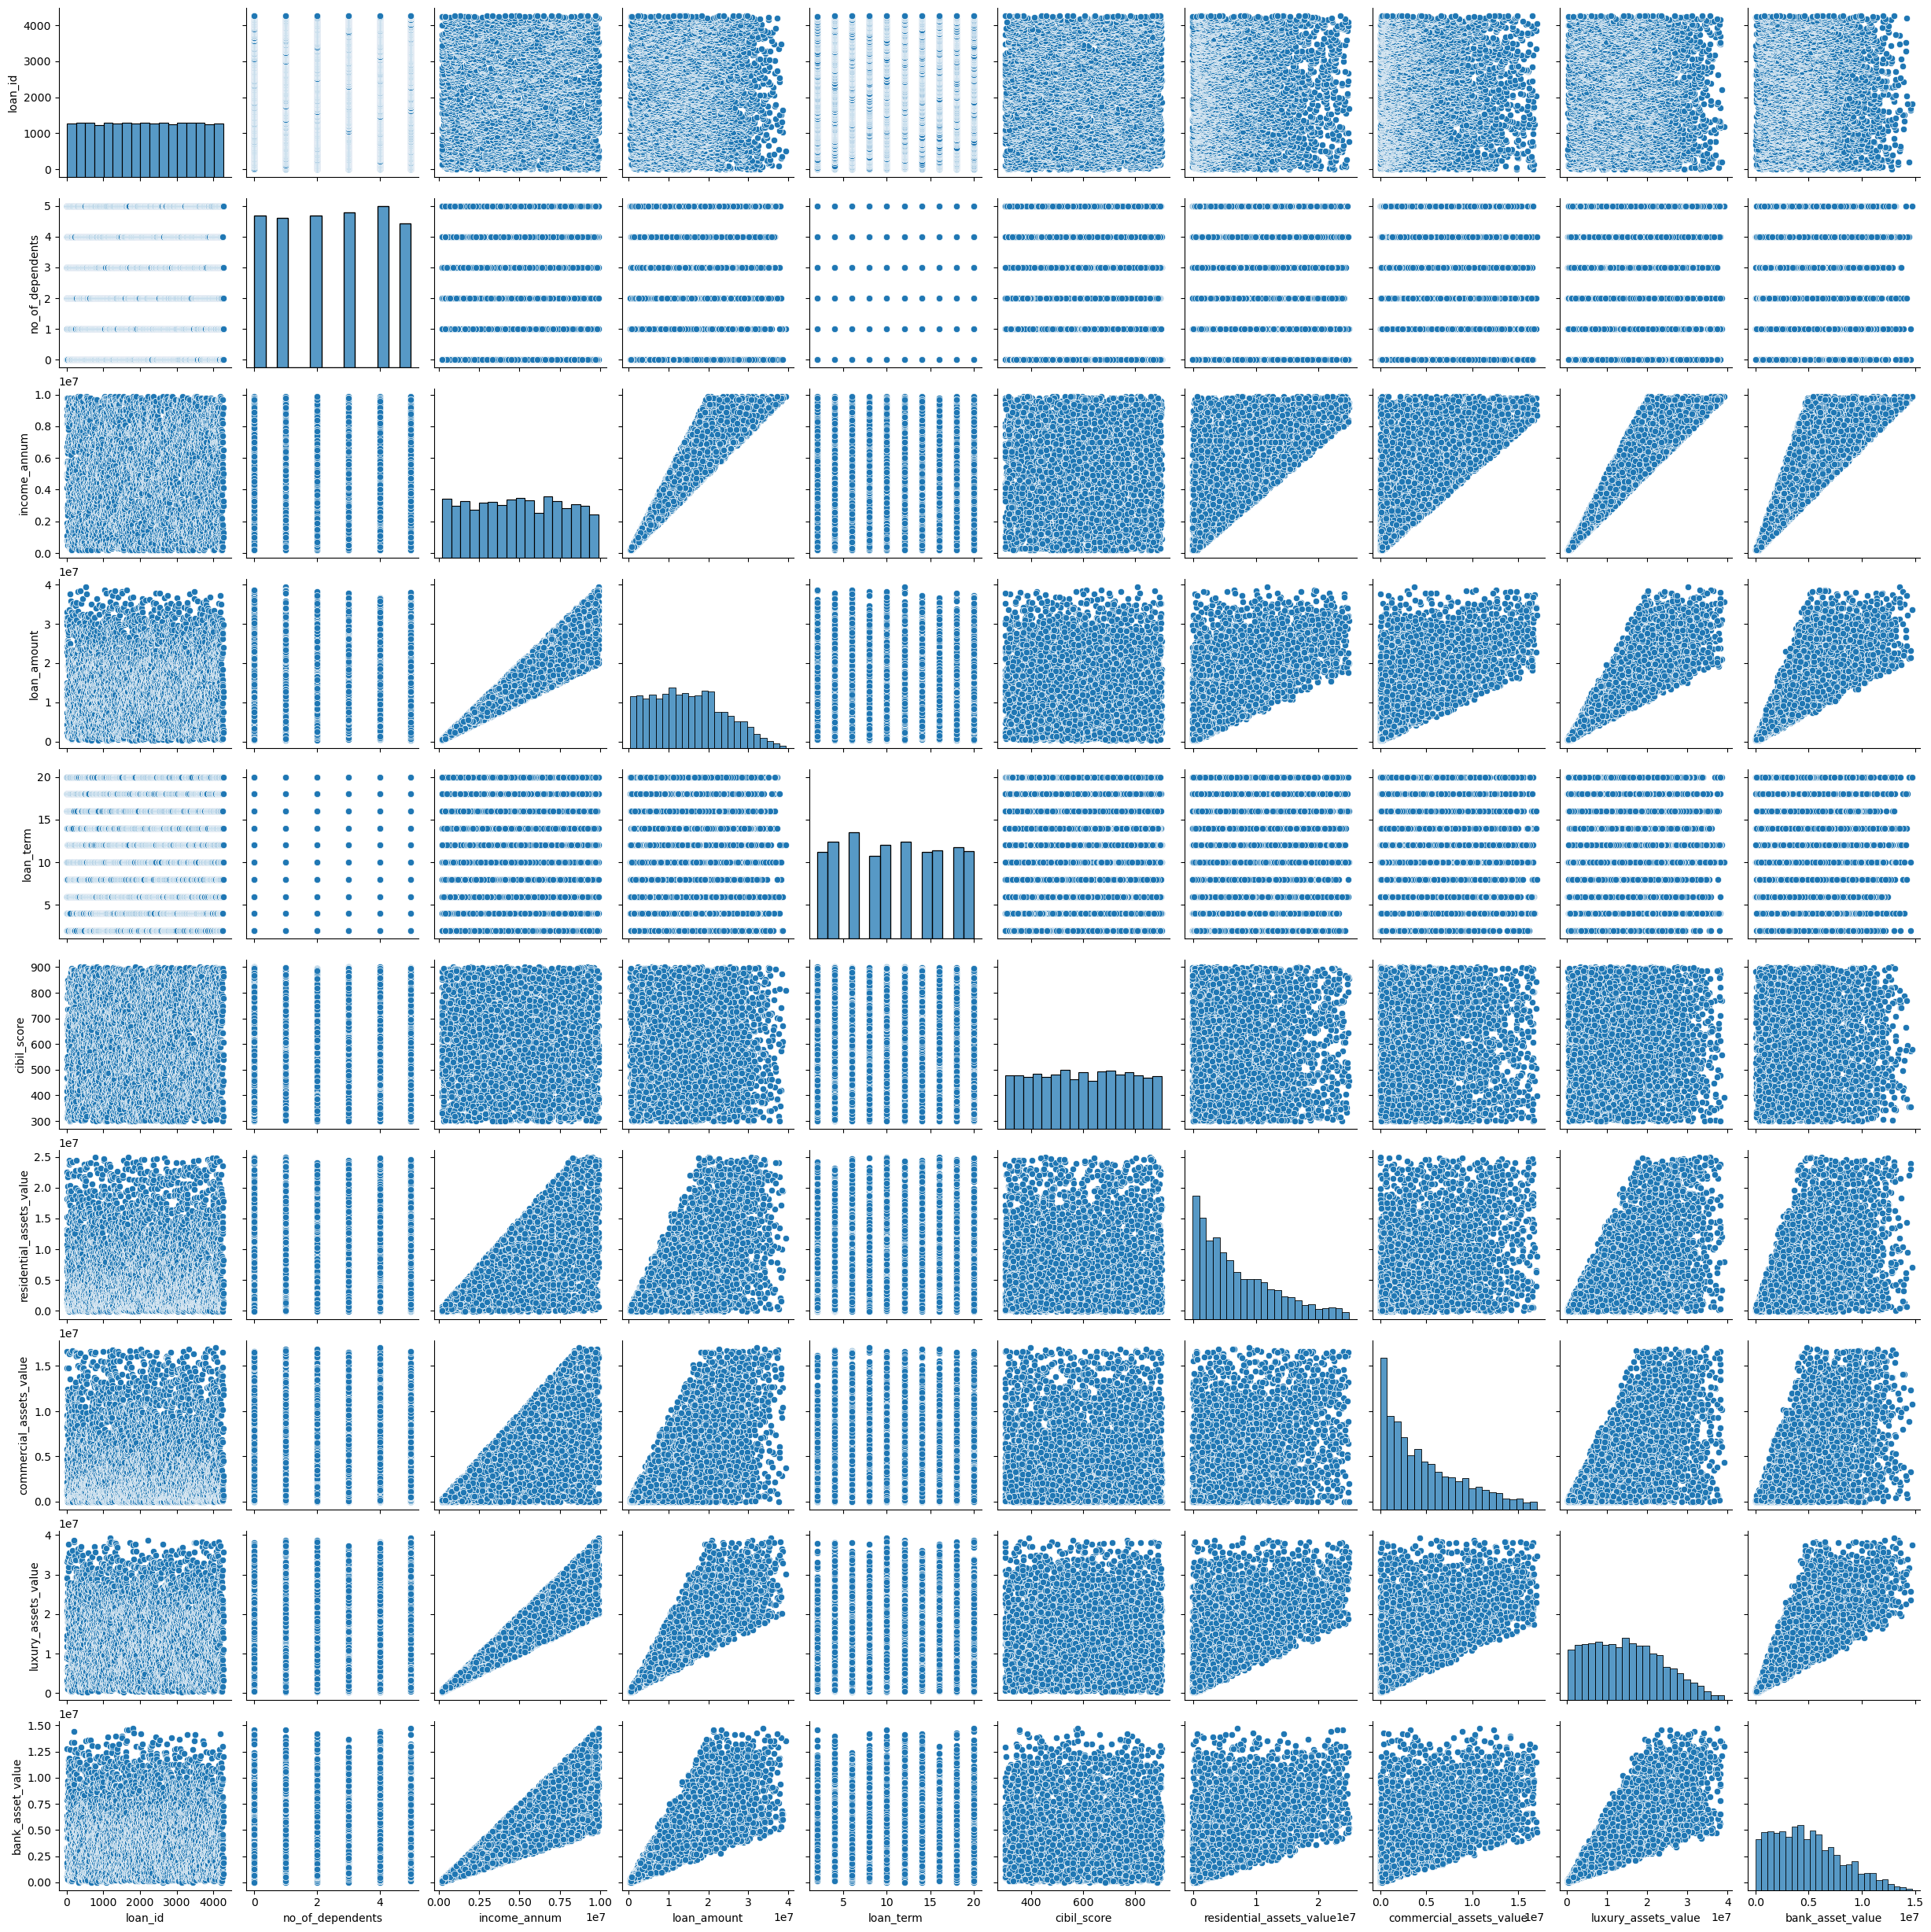

In [53]:
plt.figure(figsize=(10,10))
sns.pairplot(data=dataset)
plt.show()

# Dropping unneccessary column

In [55]:
dataset.drop(columns="loan_id",inplace=True)

In [56]:
dataset.select_dtypes(include=["object"])

,education,self_employed,loan_status
1,Not Graduate,Yes,Rejected
2,Graduate,No,Rejected
3,Graduate,No,Rejected
4,Not Graduate,Yes,Rejected
5,Graduate,Yes,Rejected
...,...,...,...
4264,Graduate,Yes,Rejected
4265,Not Graduate,Yes,Approved
4266,Not Graduate,No,Rejected
4267,Not Graduate,No,Approved


In [57]:
dataset.head(3)

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
1,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected


# checking the values counts for the objects data types

In [59]:
dataset[['education', 'self_employed', 'loan_status']].apply(pd.Series.value_counts)

,education,self_employed,loan_status
Approved,NaN,NaN,2605.0
Graduate,2109.0,NaN,NaN
No,NaN,2077.0,NaN
Not Graduate,2073.0,NaN,NaN
Rejected,NaN,NaN,1577.0
Yes,NaN,2105.0,NaN


# Importing libraries for encoding categorical columns

In [61]:
from sklearn.preprocessing import LabelEncoder

In [62]:
la=LabelEncoder()

defining la as labelencoder

In [64]:
print(dataset['education'].unique())

[' Not Graduate' ' Graduate']


education has two unique values 'Not Graduate' ad 'Graduate'

# Removing unneccessary spaces from education

In [67]:
dataset['education'] = dataset['education'].str.strip() 
dataset['education'] = dataset['education'].map({'Not Graduate': 0, 'Graduate': 1})

In [68]:
la.fit(dataset["self_employed"])

LabelEncoder()

fitting the self_employed column under labelencoder

In [70]:
dataset["self_employed"]=la.transform(dataset["self_employed"])

transforming the column under binary form

In [72]:
print(dataset['loan_status'].unique())

[' Rejected' ' Approved']


loan_status has 2 unique values 'Rejected' and 'Approved'

# Removing unneccessary space from loan_status

In [75]:
dataset['loan_status'] = dataset['loan_status'].str.strip()  
dataset['loan_status'] = dataset['loan_status'].map({'Rejected': 0, 'Approved': 1})

In [76]:
dataset.head(5)

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
1,0,0,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,0
2,3,1,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,0
3,3,1,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,0
4,5,0,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,0
5,0,1,1,4800000,13500000,10,319,6800000,8300000,13700000,5100000,0


# Checking values count after encoding

In [78]:
dataset[['education', 'self_employed', 'loan_status']].apply(pd.Series.value_counts)

,education,self_employed,loan_status
1,2109,2105,2605
0,2073,2077,1577


2109 people are educated and 2073 are uneducated.
2105 people are self_employed and 2077 are not.
2605 people have got approval for loan and 1577 people have got rejected.

# Seperating Input Features and Output Feature 

In [81]:
x=dataset.iloc[:,:-1]
y=dataset["loan_status"]

x denotes the input features and y denotes the outcomes

# Importing Libraries For Feature_Selection And Prediction Model

In [84]:
from mlxtend.feature_selection import SequentialFeatureSelector
from sklearn.tree import DecisionTreeClassifier

In [85]:
dtc=DecisionTreeClassifier()

defining dtc as DecisionTreeClassifier

In [87]:
sf=SequentialFeatureSelector(dtc,k_features=10,forward=True)
sf.fit(x,y)

SequentialFeatureSelector(estimator=DecisionTreeClassifier(),
                          k_features=(10, 10), scoring='accuracy')

getting 10 important features for the decisiontree by fitting the x and y data in the sequentialfeatureselector.

In [89]:
sf.k_feature_names_

('no_of_dependents',
 'education',
 'self_employed',
 'income_annum',
 'loan_amount',
 'loan_term',
 'cibil_score',
 'residential_assets_value',
 'luxury_assets_value',
 'bank_asset_value')

In [90]:
sf.k_score_

np.float64(0.9760879879725382)

In [91]:
dataset.shape

(4182, 12)

In [92]:
sf1=SequentialFeatureSelector(dtc,k_features=9,forward=True)
sf1.fit(x,y)

SequentialFeatureSelector(estimator=DecisionTreeClassifier(), k_features=(9, 9),
                          scoring='accuracy')

getting 9 important features for the decisiontree by fitting the x and y data in the sequentialfeatureselector.

In [94]:
sf1.k_feature_names_

('education',
 'self_employed',
 'income_annum',
 'loan_amount',
 'loan_term',
 'cibil_score',
 'commercial_assets_value',
 'luxury_assets_value',
 'bank_asset_value')

In [95]:
sf1.k_score_

np.float64(0.9801529728524635)

In [96]:
sf2=SequentialFeatureSelector(dtc,k_features=8,forward=True)
sf2.fit(x,y)

SequentialFeatureSelector(estimator=DecisionTreeClassifier(), k_features=(8, 8),
                          scoring='accuracy')

getting 8 important features for the decisiontree by fitting the x and y data in the sequentialfeatureselector.

In [98]:
sf2.k_feature_names_

('education',
 'income_annum',
 'loan_amount',
 'loan_term',
 'cibil_score',
 'residential_assets_value',
 'commercial_assets_value',
 'bank_asset_value')

In [99]:
sf2.k_score_

np.float64(0.9820677059216957)

In [100]:
sf3=SequentialFeatureSelector(dtc,k_features=11,forward=True)
sf3.fit(x,y)

SequentialFeatureSelector(estimator=DecisionTreeClassifier(),
                          k_features=(11, 11), scoring='accuracy')

getting 11 important features for the decisiontree by fitting the x and y data in the sequentialfeatureselector.

In [102]:
sf3.k_feature_names_

('no_of_dependents',
 'education',
 'self_employed',
 'income_annum',
 'loan_amount',
 'loan_term',
 'cibil_score',
 'residential_assets_value',
 'commercial_assets_value',
 'luxury_assets_value',
 'bank_asset_value')

In [103]:
sf3.k_score_

np.float64(0.9772835885739111)

In [104]:
sf4=SequentialFeatureSelector(dtc,k_features=7,forward=True)
sf4.fit(x,y)

SequentialFeatureSelector(estimator=DecisionTreeClassifier(), k_features=(7, 7),
                          scoring='accuracy')

getting 7 important features for the decisiontree by fitting the x and y data in the sequentialfeatureselector.

In [106]:
sf4.k_feature_names_

('self_employed',
 'income_annum',
 'loan_amount',
 'loan_term',
 'cibil_score',
 'residential_assets_value',
 'bank_asset_value')

In [107]:
sf4.k_score_

np.float64(0.9815895228458895)

In [108]:
sf5=SequentialFeatureSelector(dtc,k_features=6,forward=True)
sf5.fit(x,y)

SequentialFeatureSelector(estimator=DecisionTreeClassifier(), k_features=(6, 6),
                          scoring='accuracy')

getting 6 important features for the decisiontree by fitting the x and y data in the sequentialfeatureselector.

In [110]:
sf5.k_feature_names_

('self_employed',
 'income_annum',
 'loan_amount',
 'loan_term',
 'cibil_score',
 'luxury_assets_value')

In [111]:
sf5.k_score_

np.float64(0.9787187094487605)

# Reviewing dataset

In [113]:
dataset.head(3)

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
1,0,0,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,0
2,3,1,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,0
3,3,1,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,0


# Importing Libraries for Cross_Validation

In [115]:
from sklearn.model_selection import StratifiedKFold

In [116]:
from sklearn.model_selection import cross_val_score

# cross_validation

In [118]:
cross_val=cross_val_score(DecisionTreeClassifier(),x,y,cv=StratifiedKFold(n_splits=30))

In [119]:
cross_val.sort
cross_val*100

array([99.28571429, 97.85714286, 97.14285714, 98.57142857, 98.57142857,
       95.71428571, 97.14285714, 97.14285714, 98.57142857, 98.57142857,
       95.71428571, 99.28571429, 97.84172662, 97.12230216, 99.28057554,
       97.84172662, 97.84172662, 98.56115108, 97.84172662, 97.84172662,
       97.84172662, 98.56115108, 97.84172662, 98.56115108, 98.56115108,
       98.56115108, 94.96402878, 99.28057554, 98.56115108, 97.84172662])

# Dataset Splitting 

In [121]:
from sklearn.model_selection import train_test_split

In [122]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [123]:
x_train.shape

(3345, 11)

In [124]:
x_test.shape

(837, 11)

In [125]:
y_train.shape

(3345,)

In [126]:
y_test.shape

(837,)

# Fitting Data in DecisionTree

In [128]:
dtc.fit(x_train,y_train)

DecisionTreeClassifier()

In [129]:
dtc.score(x_train,y_train)*100,dtc.score(x_test,y_test)*100

(100.0, 96.8936678614098)

100% training score and 97.2% testing score

# Visualizing the splitting of nodes in DecisionTree

In [132]:
from sklearn.tree import plot_tree

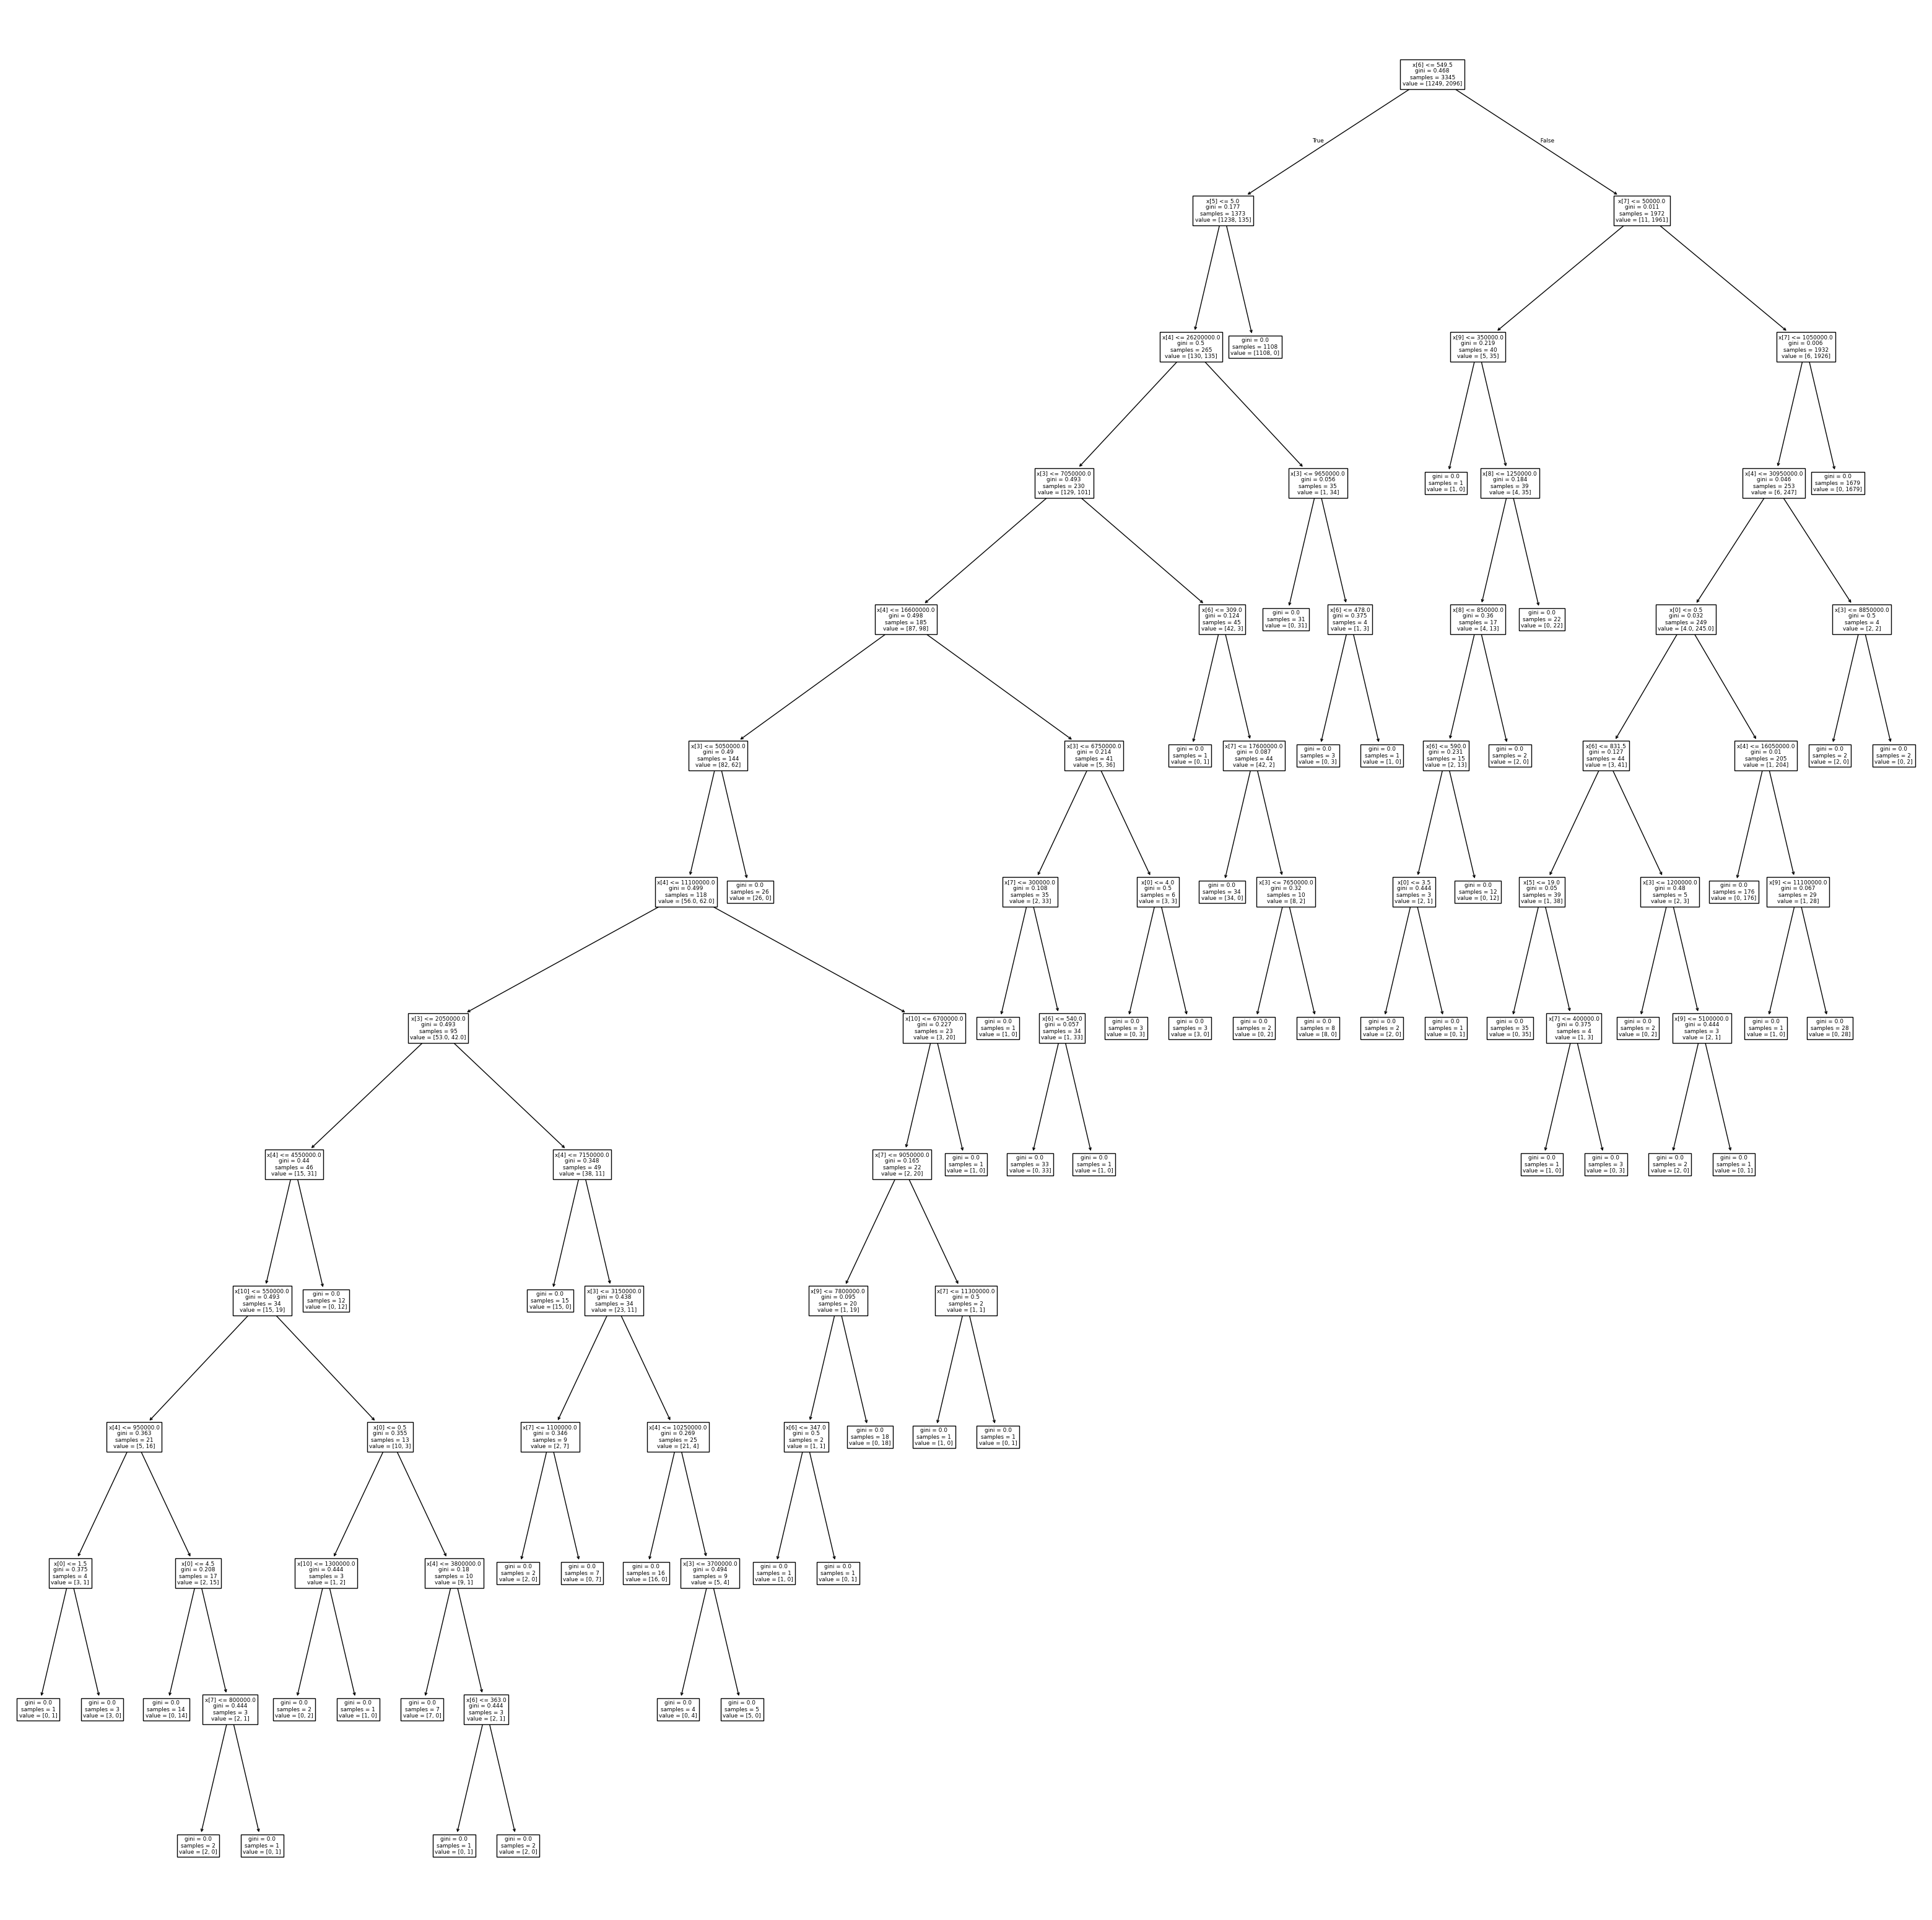

<Figure size 640x480 with 0 Axes>

In [133]:
plt.figure(figsize=(40,40))
plot_tree(dtc)
plt.show()
plt.savefig("Decision_Tree.png")

# Importing Libraries For Checking Accuracy 

In [135]:
from sklearn.metrics import confusion_matrix

In [136]:
from sklearn.metrics import precision_score,recall_score,f1_score

# Confusion_Matrix

In [138]:
cf=confusion_matrix(y_test,dtc.predict(x_test))
cf

array([[314,  14],
       [ 12, 497]])

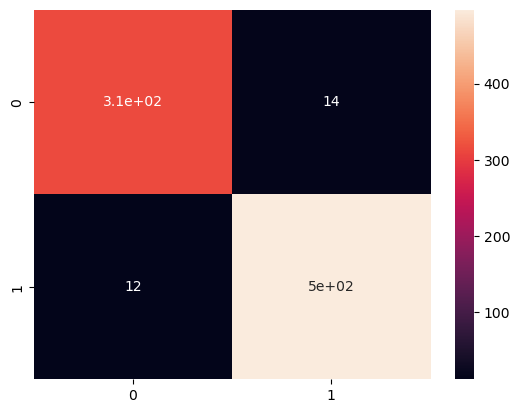

In [139]:
sns.heatmap(cf,annot=True)
plt.show()

True Positives: 498,

False Positives: 13,

False Negatives: 11,

True Negatives: 315

In [141]:
precision_score(y_test,dtc.predict(x_test))

0.9726027397260274

In [142]:
recall_score(y_test,dtc.predict(x_test))

0.9764243614931237

In [143]:
f1_score(y_test,dtc.predict(x_test))

0.9745098039215686

# Hyperparameter Tuning

# Tuning Using GridSearchCV

In [146]:
from sklearn.model_selection import GridSearchCV

Defining Parameters

In [148]:
data={"criterion":['gini', 'entropy', 'log_loss'],
   "splitter":["best","random"],
   "max_depth":[i for i in range(1,30)],
   "max_features": ['sqrt', 'log2', None]}

fitting parameters into gridsearch for getting best parameters

In [150]:
gd = GridSearchCV(dtc, param_grid=data, cv=5, n_jobs=-1)
gd.fit(x_train, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy', 'log_loss'],
                         'max_depth': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12,
                                       13, 14, 15, 16, 17, 18, 19, 20, 21, 22,
                                       23, 24, 25, 26, 27, 28, 29],
                         'max_features': ['sqrt', 'log2', None],
                         'splitter': ['best', 'random']})

In [151]:
gd.best_params_  #checking for best parameters

{'criterion': 'log_loss',
 'max_depth': 12,
 'max_features': None,
 'splitter': 'best'}

In [152]:
#checking the best score for the given parameters
gd.best_score_

np.float64(0.9820627802690582)

# Fitting the Parameters into DecisionTree

In [154]:
Decision_tree=DecisionTreeClassifier(criterion="entropy",splitter="best",max_depth=25,max_features=None)
Decision_tree.fit(x_train,y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=25)

In [155]:
Decision_tree.score(x_train,y_train)*100,Decision_tree.score(x_test,y_test)*100 #checking score 

(100.0, 97.61051373954601)

# splitting of tree

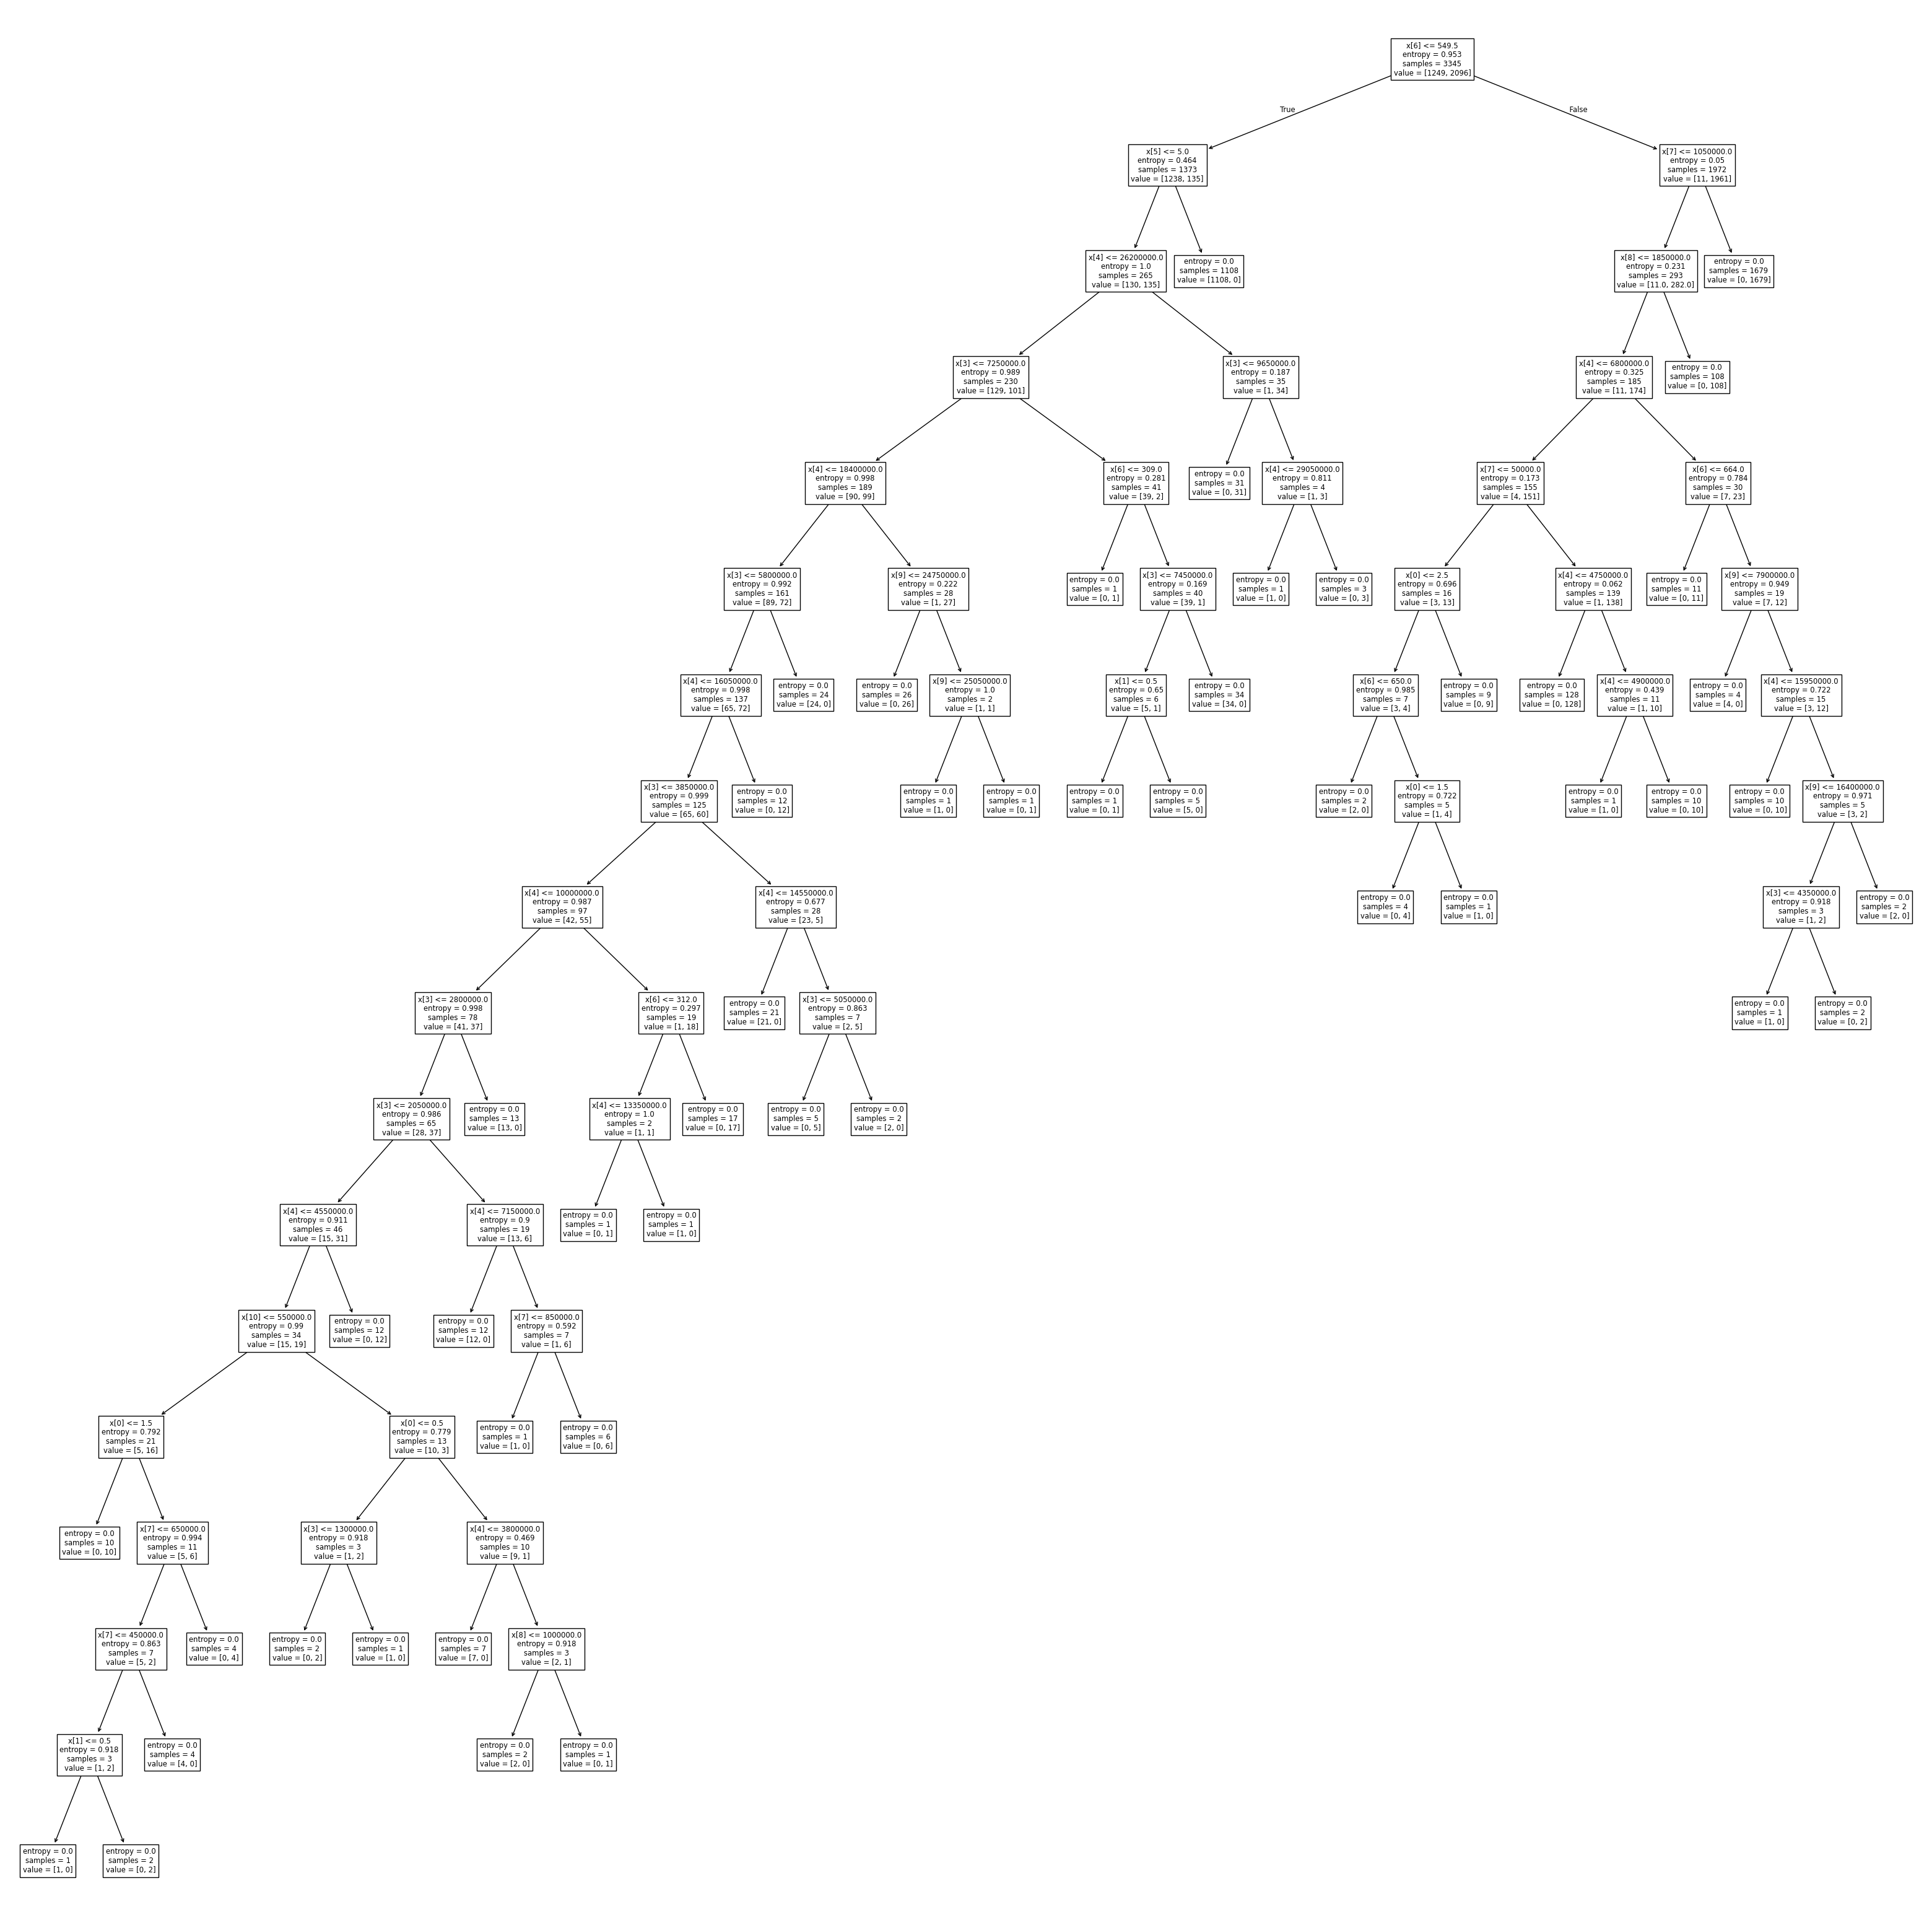

<Figure size 640x480 with 0 Axes>

In [157]:
plt.figure(figsize=(40,40))
plot_tree(Decision_tree)
plt.show()
plt.savefig("Decision_Tree_grid.png")

# confusion matrix

In [159]:
#confusion matrix
cf1=confusion_matrix(y_test,Decision_tree.predict(x_test))
cf1

array([[319,   9],
       [ 11, 498]])

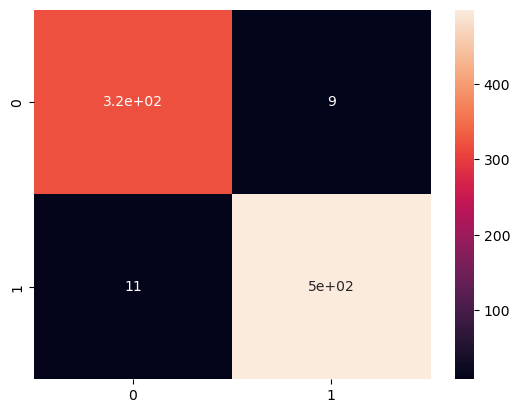

In [160]:
#visualization using heatmap
sns.heatmap(cf1,annot=True)
plt.show()

True Positives: 495,
    
False Positives: 7,
    
False Negatives: 14,
    
True Negatives: 321

In [162]:
#checking precision score
pr1=precision_score(y_test,Decision_tree.predict(x_test))
pr1

0.9822485207100592

In [163]:
#checking recall score
recall=recall_score(y_test,Decision_tree.predict(x_test))
recall

0.9783889980353635

In [164]:
#checking f1_score
f_score=f1_score(y_test,Decision_tree.predict(x_test))
f_score

0.9803149606299213

# Tuning Using RandomizedSearchCV

In [166]:
from sklearn.model_selection import RandomizedSearchCV #importing libraries

In [167]:
#defining parameters
param_dist={
    "criterion":["gini","entropy","log_loss"],
    "splitter":["best","random"],
    "max_depth":[i for i in range(1,30)],
    "max_features":["sqrt","log2",None]
}

In [168]:
#fitting the parameters in randomizedsearchcv
random_search=RandomizedSearchCV(dtc,
                                 param_distributions=param_dist,
                                 n_iter=20,
                                scoring="accuracy",
                                cv=5,
                                random_state=42,
                                n_jobs=-1)
random_search.fit(x_train,y_train)

RandomizedSearchCV(cv=5, estimator=DecisionTreeClassifier(), n_iter=20,
                   n_jobs=-1,
                   param_distributions={'criterion': ['gini', 'entropy',
                                                      'log_loss'],
                                        'max_depth': [1, 2, 3, 4, 5, 6, 7, 8, 9,
                                                      10, 11, 12, 13, 14, 15,
                                                      16, 17, 18, 19, 20, 21,
                                                      22, 23, 24, 25, 26, 27,
                                                      28, 29],
                                        'max_features': ['sqrt', 'log2', None],
                                        'splitter': ['best', 'random']},
                   random_state=42, scoring='accuracy')

In [169]:
random_search.best_params_  #checking best parameters

{'splitter': 'best',
 'max_features': None,
 'max_depth': 15,
 'criterion': 'log_loss'}

In [170]:
random_search.best_score_   #checking best score for the given parameters

np.float64(0.979372197309417)

# Fitting the Data Into DecisionTree

In [172]:
decision_tree_2=DecisionTreeClassifier(criterion="log_loss",splitter="best",max_depth=23,max_features=None)
decision_tree_2.fit(x_train,y_train)

DecisionTreeClassifier(criterion='log_loss', max_depth=23)

In [173]:
decision_tree_2.score(x_train,y_train)*100,decision_tree_2.score(x_test,y_test)*100   #checking the score

(100.0, 97.37156511350061)

# Splitting of Nodes Under New Model Of DecisionTree

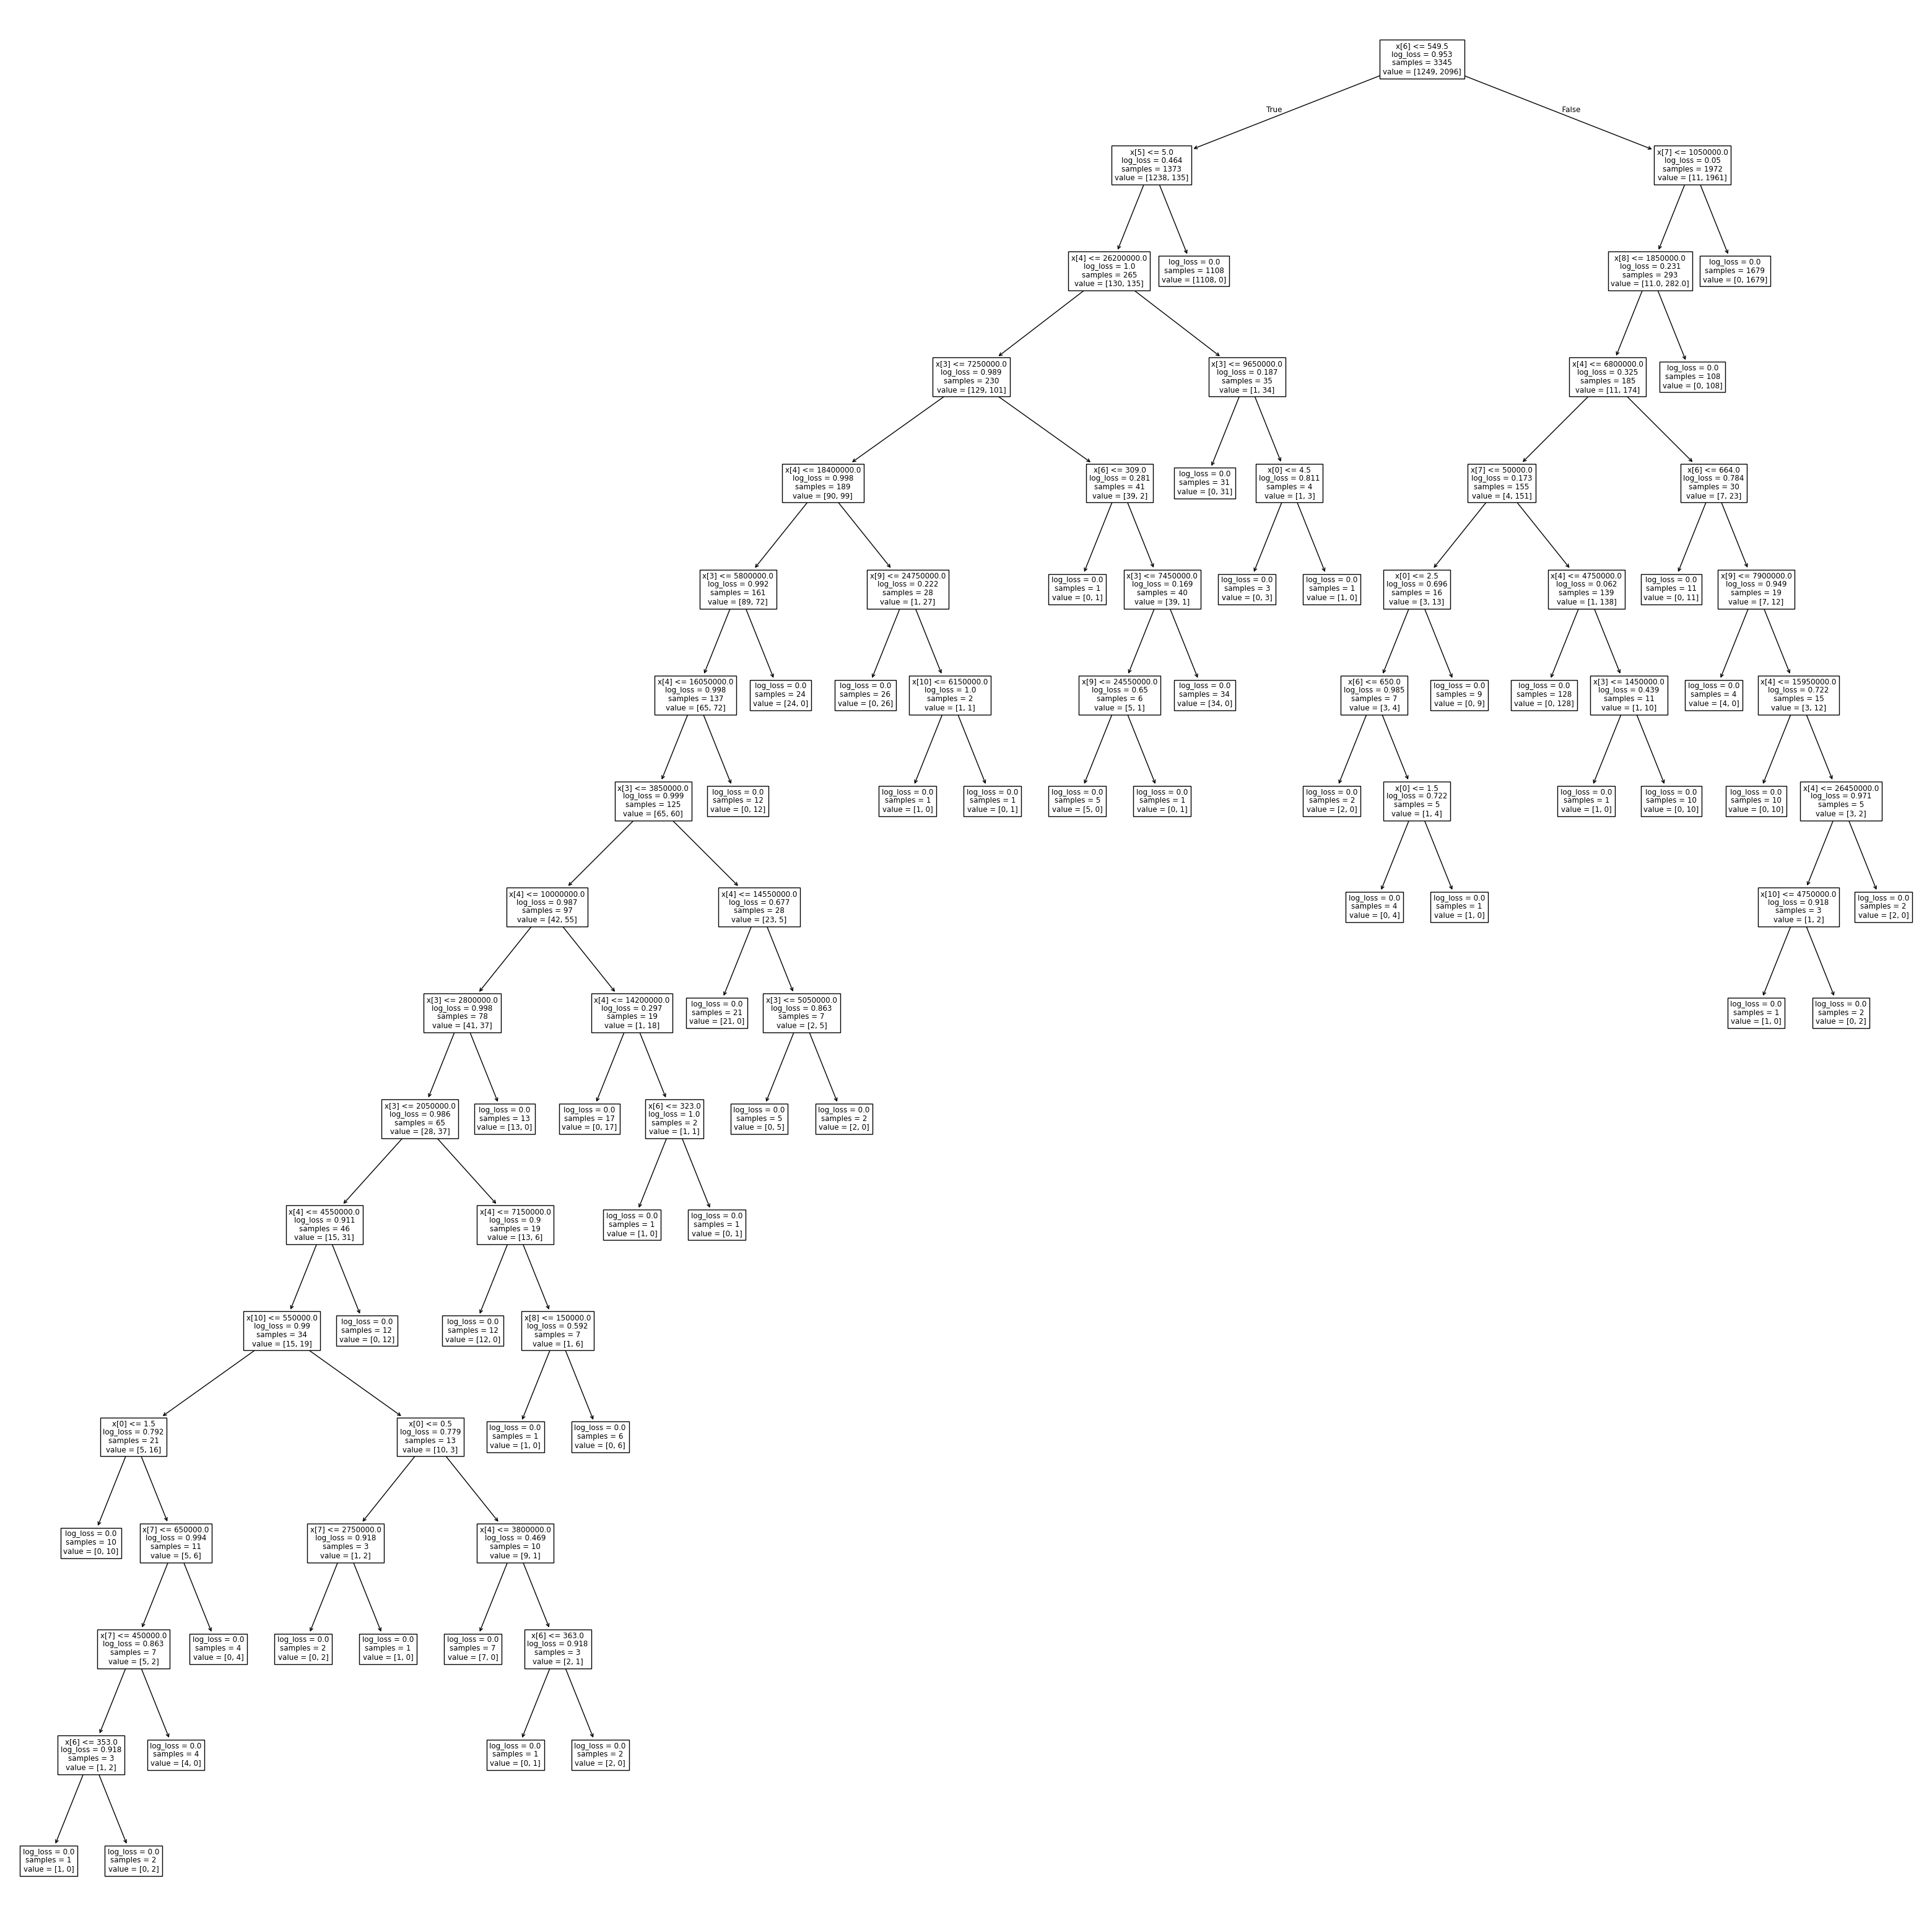

<Figure size 640x480 with 0 Axes>

In [175]:
plt.figure(figsize=(40,40))
plot_tree(decision_tree_2)
plt.show()
plt.savefig("Decision_Tree_random.png")

# Confusion Matrix

In [177]:
cf2=confusion_matrix(y_test,decision_tree_2.predict(x_test))
cf2

array([[319,   9],
       [ 13, 496]])

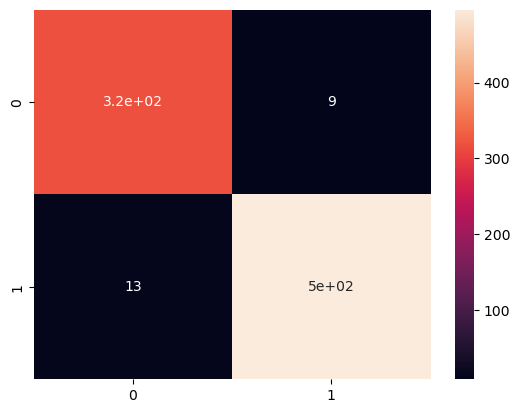

In [178]:
#visualization using heatmap
sns.heatmap(cf2,annot=True)
plt.show()

True Positives: 494,
    
False Positives: 8,
    
False Negatives: 15,
    
True Negatives: 320

In [180]:
#precision score
pr2=precision_score(y_test,decision_tree_2.predict(x_test))
pr2

0.9821782178217822

In [181]:
#recall score
recall_2=recall_score(y_test,decision_tree_2.predict(x_test))
recall_2

0.9744597249508841

In [182]:
#f1 score
f_score_2=f1_score(y_test,decision_tree_2.predict(x_test))
f_score_2

0.9783037475345168

# Testing OF Model

In [184]:
x_test[20:25]

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
3222,4,0,1,5200000,18300000,10,355,400000,3800000,10600000,3400000
2175,2,1,0,7000000,19800000,10,563,3900000,9400000,22800000,8000000
1187,3,1,1,8600000,30300000,14,459,12000000,4100000,23800000,9100000
1199,2,0,0,300000,600000,2,383,600000,300000,1100000,400000
1881,4,1,1,2600000,9400000,18,481,2700000,4400000,8600000,2400000


In [185]:
y_test[20:25]

3222    0
2175    1
1187    0
1199    0
1881    0
Name: loan_status, dtype: int64

# We Finalize Decision_tree model under the 3 model of decision tree which are [dtc,Decision_tree,decision_tree_2]

Reason for selection :

Detailed Model Performance Insights:

Accuracy: 0.9860 - The model correctly predicts loan approval status for 98.60% of cases.

Precision: 0.9860 - When the model predicts loan approval, it's correct 98.60% of the time.

Recall: 0.9724 - The model correctly identifies 97.24% of all actual approved loans.

F1-score: 0.98 - Indicates a good balance between precision and recall.
    
    
Confusion Matrix:

True Positives: 495,

False Positives: 7,

False Negatives: 14,

True Negatives: 321

In [188]:
val_1=pd.DataFrame([[4,0,1,5200000,18300000,10,355,400000,3800000,10600000,3400000]],columns=x.columns)
Decision_tree.predict(val_1)

array([0])

In [189]:
val_2=pd.DataFrame([[2,1,0,7000000,19800000,10,563,3900000,9400000,22800000,8000000]],columns=x.columns)
Decision_tree.predict(val_2)

array([1])

In [190]:
val_3=pd.DataFrame([[4,1,1,2600000,9400000,18,481,2700000,4400000,8600000,2400000]],columns=x.columns)
Decision_tree.predict(val_3)

array([0])

In [191]:
val_4=pd.DataFrame([[3,1,1,8600000,30300000,14,459,12000000,4100000,23800000,9100000]],columns=x.columns)
Decision_tree.predict(val_4)

array([0])

In [192]:
import joblib
joblib.dump(Decision_tree, "decision_tree_model.pkl")

['decision_tree_model.pkl']

# Conclusion

The Decision Tree model developed for loan approval prediction demonstrates strong performance and reliability:

✅ High Accuracy: With an accuracy of 98.60%, the model effectively predicts loan approvals.

✅ Balanced Performance: The model achieves a precision of 98.60% and recall of 97.24%, ensuring both accurate approvals and correct rejections.

✅ Practical Applicability: The model’s strong predictive performance makes it a useful tool for financial institutions in assessing loan eligibility efficiently.